# Taller: Abandono de producto financiero

## Regresión logística en Python · Clase 9

**Estudiantes:** Nicolás Montenegro Cedeño - Nicolás Barona
**Base:** `abandono_producto_financiero.csv` (10.000 clientes, corte transversal)

---

### El problema

Una entidad de banca de personas registró un aumento de clientes que cierran la relación. El
área de retención necesita pasar de la tasa agregada de la cartera a una probabilidad
individual:

$$
P(\text{abandono}=1 \mid x) = \Lambda(x\beta) = \frac{e^{x\beta}}{1 + e^{x\beta}} \in (0,1)
$$

El cálculo no sustituye la decisión comercial: ordena la cartera. Dice a quién contactar
primero, con qué umbral se declara a un cliente «en riesgo» y qué error se acepta, llamar a quien
se iba a quedar (falso positivo) frente a no ver a quien sí se va (falso negativo).

`abandono = 1` significa que el cliente cerró la relación; `abandono = 0`, que permanece. No es
mora ni *default*.

### Recorrido

| Sección | Qué se hace | Preguntas |
|---|---|---|
| 1 | Cargar, tipificar y contar variables | 1–4 |
| 2 | Univariado de $y$ y de las $x$ | 5 |
| 3 | Bivariado con `abandono` (boxplots, tablas, ji-cuadrado) | 6–10 |
| 4 | De la recta OLS al logit simple (edad) | 11–13 |
| 5 | Varios logits, AIC, odds ratios | 14–16 |
| 6 | Test, umbral, matriz de confusión e indicadores | 17–18 |
| 7 | Dos perfiles y lectura de riesgo | 19–21 |

Las respuestas están en celdas Markdown debajo de cada bloque de código, y todas las cifras
citadas provienen de esta corrida.

---

## 0. Configuración

Paquetes de clase: `pandas`, `numpy`, `matplotlib`, `statsmodels`, `scipy`. No se usa `sklearn`,
porque el objetivo es inferencia (coeficientes, errores estándar, *odds ratios*) y no solo
predicción.

El CSV debe estar en la misma carpeta que este cuaderno, con el nombre
`abandono_producto_financiero.csv`.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats
import statsmodels
import statsmodels.formula.api as smf
from scipy.stats import chi2_contingency

warnings.filterwarnings("ignore")

pd.set_option("display.width", 150)
pd.set_option("display.max_columns", 30)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# Paleta fija para las dos clases de la respuesta
COL_PERM, COL_ABAN = "#2C5697", "#C0392B"

print("Versiones utilizadas")
print("-" * 32)
for nombre, mod in [("pandas", pd), ("numpy", np), ("statsmodels", statsmodels),
                    ("scipy", scipy)]:
    print(f"{nombre:12s} {mod.__version__}")

Versiones utilizadas
--------------------------------
pandas       3.0.3
numpy        2.5.0
statsmodels  0.14.6
scipy        1.18.0


In [2]:
# Localización del archivo (debe estar junto al cuaderno)
CANDIDATOS = [Path("abandono_producto_financiero.csv"),
              Path.home() / "Downloads" / "abandono_producto_financiero.csv",
              Path.home() / "Descargas" / "abandono_producto_financiero.csv"]
RUTA = next((p for p in CANDIDATOS if p.exists()), None)
if RUTA is None:
    raise FileNotFoundError(
        "No se encontró abandono_producto_financiero.csv. "
        "Colóquelo junto a este cuaderno.")
print(f"Archivo de datos: {RUTA.resolve()}")

Archivo de datos: C:\Users\nicom\Downloads\abandono_producto_financiero.csv


---

# 1. Estructura de los datos

Se carga la base, se inspecciona, se eliminan los identificadores que no entran a la fórmula
(`numero_fila`, `id_cliente`, `apellido`) y se fijan los tipos:

- `pais` → categórica con niveles Francia, Alemania, España (referencia: Francia)
- `sexo` → categórica con niveles Mujer, Hombre (referencia: Mujer)
- `abandono` → entero 0/1

El orden de los niveles importa: es lo que hace que `C(pais)` y `C(sexo)` usen las mismas
referencias que el enunciado.

In [3]:
df = pd.read_csv(RUTA)

print("PRIMERAS OBSERVACIONES")
display(df.head())
print(f"\nDimensión de la base cruda: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"\nColumnas: {list(df.columns)}")

PRIMERAS OBSERVACIONES


,numero_fila,id_cliente,apellido,puntaje_crediticio,pais,sexo,edad,antiguedad,saldo,numero_productos,tiene_tarjeta,miembro_activo,salario_estimado,abandono
0,1,15634602,Hargrave,619,Francia,Mujer,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,España,Mujer,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,Francia,Mujer,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,Francia,Mujer,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,España,Mujer,43,2,125510.82,1,1,1,79084.10,0



Dimensión de la base cruda: 10000 filas x 14 columnas

Columnas: ['numero_fila', 'id_cliente', 'apellido', 'puntaje_crediticio', 'pais', 'sexo', 'edad', 'antiguedad', 'saldo', 'numero_productos', 'tiene_tarjeta', 'miembro_activo', 'salario_estimado', 'abandono']


In [4]:
print("TIPOS DE DATO ASIGNADOS POR PANDAS")
print(df.dtypes.to_string())
print("\nINFORMACIÓN GENERAL")
df.info()

TIPOS DE DATO ASIGNADOS POR PANDAS
numero_fila             int64
id_cliente              int64
apellido                  str
puntaje_crediticio      int64
pais                      str
sexo                      str
edad                    int64
antiguedad              int64
saldo                 float64
numero_productos        int64
tiene_tarjeta           int64
miembro_activo          int64
salario_estimado      float64
abandono                int64

INFORMACIÓN GENERAL
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   numero_fila         10000 non-null  int64  
 1   id_cliente          10000 non-null  int64  
 2   apellido            10000 non-null  str    
 3   puntaje_crediticio  10000 non-null  int64  
 4   pais                10000 non-null  str    
 5   sexo                10000 non-null  str    
 6   edad                10000 non-

In [5]:
print("DESCRIPTIVO DE LA BASE CRUDA (variables numéricas)")
display(df.describe().T.round(2))

print("\nCONTROL DE CALIDAD")
print(f"  Valores faltantes      : {int(df.isna().sum().sum())}")
print(f"  Filas duplicadas       : {int(df.duplicated().sum())}")
print(f"  id_cliente únicos      : {df['id_cliente'].nunique()} de {len(df)}")
print(f"  ¿Una fila por cliente? : {df['id_cliente'].nunique() == len(df)}")

DESCRIPTIVO DE LA BASE CRUDA (variables numéricas)


,count,mean,std,min,25%,50%,75%,max
numero_fila,10000.0,5000.50,2886.90,1.00,2500.75,5000.50,7500.25,10000.00
id_cliente,10000.0,15690940.57,71936.19,15565701.00,15628528.25,15690738.00,15753233.75,15815690.00
puntaje_crediticio,10000.0,650.53,96.65,350.00,584.00,652.00,718.00,850.00
edad,10000.0,38.92,10.49,18.00,32.00,37.00,44.00,92.00
antiguedad,10000.0,5.01,2.89,0.00,3.00,5.00,7.00,10.00
saldo,10000.0,76485.89,62397.41,0.00,0.00,97198.54,127644.24,250898.09
numero_productos,10000.0,1.53,0.58,1.00,1.00,1.00,2.00,4.00
tiene_tarjeta,10000.0,0.71,0.46,0.00,0.00,1.00,1.00,1.00
miembro_activo,10000.0,0.52,0.50,0.00,0.00,1.00,1.00,1.00
salario_estimado,10000.0,100090.24,57510.49,11.58,51002.11,100193.92,149388.25,199992.48



CONTROL DE CALIDAD
  Valores faltantes      : 0
  Filas duplicadas       : 0
  id_cliente únicos      : 10000 de 10000
  ¿Una fila por cliente? : True


In [6]:
# Identificadores fuera + tipificación de factores
datos = df.drop(columns=["numero_fila", "id_cliente", "apellido"]).copy()

datos["pais"] = pd.Categorical(datos["pais"],
                               categories=["Francia", "Alemania", "España"])
datos["sexo"] = pd.Categorical(datos["sexo"],
                               categories=["Mujer", "Hombre"])
datos["abandono"] = datos["abandono"].astype(int)

print(f"Base de modelación: {datos.shape[0]} filas x {datos.shape[1]} columnas")
print(f"Variables eliminadas: numero_fila, id_cliente, apellido\n")
print(datos.dtypes.to_string())
print(f"\nNiveles de pais : {list(datos['pais'].cat.categories)}  "
      f"(referencia = {datos['pais'].cat.categories[0]})")
print(f"Niveles de sexo : {list(datos['sexo'].cat.categories)}  "
      f"(referencia = {datos['sexo'].cat.categories[0]})")

Base de modelación: 10000 filas x 11 columnas
Variables eliminadas: numero_fila, id_cliente, apellido

puntaje_crediticio       int64
pais                  category
sexo                  category
edad                     int64
antiguedad               int64
saldo                  float64
numero_productos         int64
tiene_tarjeta            int64
miembro_activo           int64
salario_estimado       float64
abandono                 int64

Niveles de pais : ['Francia', 'Alemania', 'España']  (referencia = Francia)
Niveles de sexo : ['Mujer', 'Hombre']  (referencia = Mujer)


In [7]:
# Clasificación explícita de las variables de modelación
CUANTITATIVAS = ["puntaje_crediticio", "edad", "antiguedad", "saldo",
                 "numero_productos", "salario_estimado"]
CATEGORICAS = ["pais", "sexo"]
BINARIAS = ["tiene_tarjeta", "miembro_activo"]
RESPUESTA = "abandono"

clasificacion = pd.DataFrame(
    [(v, "Cuantitativa", "Continua") for v in CUANTITATIVAS]
    + [(v, "Categórica", f"C({v}); ref. {datos[v].cat.categories[0]}") for v in CATEGORICAS]
    + [(v, "Binaria", "0 / 1") for v in BINARIAS]
    + [(RESPUESTA, "Binaria", "Respuesta y")],
    columns=["Variable", "Tipo", "Uso en el logit"])
display(clasificacion)

print(f"Cuantitativas                        : {len(CUANTITATIVAS)}")
print(f"Categóricas + binarias (con abandono): "
      f"{len(CATEGORICAS) + len(BINARIAS) + 1}")
print(f"Total de variables de modelación     : "
      f"{len(CUANTITATIVAS) + len(CATEGORICAS) + len(BINARIAS) + 1}")

,Variable,Tipo,Uso en el logit
0,puntaje_crediticio,Cuantitativa,Continua
1,edad,Cuantitativa,Continua
2,antiguedad,Cuantitativa,Continua
3,saldo,Cuantitativa,Continua
4,numero_productos,Cuantitativa,Continua
5,salario_estimado,Cuantitativa,Continua
6,pais,Categórica,C(pais); ref. Francia
7,sexo,Categórica,C(sexo); ref. Mujer
8,tiene_tarjeta,Binaria,0 / 1
9,miembro_activo,Binaria,0 / 1


Cuantitativas                        : 6
Categóricas + binarias (con abandono): 5
Total de variables de modelación     : 11


### Respuestas (sección 1)

**1. ¿Cuántas variables tiene la base cruda? ¿Cuántas quedan para el modelo?**

La base cruda tiene 14 variables. Se eliminan tres identificadores: `numero_fila`
(número de fila), `id_cliente` (llave administrativa) y `apellido` (texto libre), porque no son
atributos del cliente que puedan explicar su decisión: son etiquetas. Quedan 11 variables:
10 explicativas más la respuesta `abandono`.

**2. ¿Cuántas son cuantitativas?**

Seis: `puntaje_crediticio`, `edad`, `antiguedad`, `saldo`, `numero_productos` y
`salario_estimado`. `numero_productos` es un conteo entero (1 a 4), pero el diccionario indica
tratarlo como continua dentro del logit.

**3. ¿Cuántas son categóricas o binarias (incluyendo `abandono`)?**

Cinco: `pais` (3 niveles), `sexo` (2 niveles), `tiene_tarjeta` (0/1), `miembro_activo` (0/1) y
la respuesta `abandono` (0/1). Seis cuantitativas más cinco categóricas suman las 11 variables de
modelación.

**4. ¿Qué implica esta mezcla para el logit en Python (`C(pais)`, `C(sexo)` frente a dummies hechas a mano)?**

Implica que hay que decidir cómo entran los factores, y `C()` lo resuelve de forma más segura
que construir dummies manualmente, por cuatro razones:

1. **Fija la referencia de manera explícita y estable.** Al declarar `pais` como `Categorical` con
   el orden *Francia, Alemania, España*, `C(pais)` toma Francia como base. Sin ese paso, pandas
   ordenaría alfabéticamente (*Alemania, España, Francia*) y los coeficientes se leerían contra
   Alemania, cambiando la interpretación de todos los *odds ratios* del país.
2. **Evita la trampa de la variable ficticia.** `C()` genera $k-1$ columnas automáticamente. Crear
   las $k$ dummies a mano produce colinealidad perfecta con el intercepto.
3. **Garantiza consistencia entre conjuntos de datos.** La misma fórmula se aplica a `Train_Data`,
   a `Test_Data` y al DataFrame de perfiles de la sección 7. Con dummies manuales habría que
   replicar exactamente la misma codificación en cada objeto nuevo, y ahí es donde se cuelan los
   errores silenciosos.
4. **`statsmodels` reconoce el bloque.** Sabe que las dummies de un mismo factor pertenecen a una
   sola variable, lo que permite contrastes conjuntos sobre todo el factor.

Las variables ya binarias (`tiene_tarjeta`, `miembro_activo`) no necesitan `C()`: al estar
codificadas 0/1, su coeficiente ya se lee como el efecto de pasar de 0 a 1.

---
> 📌 Cierre de sección: `git commit -m "Punto 1: estructura de los datos"` y `git push`.

---

# 2. Descriptivo univariado

Primero la respuesta (cuántos abandonan y en qué proporción) y después la forma de las
explicativas.

In [8]:
conteo = datos["abandono"].value_counts().sort_index()
propor = datos["abandono"].value_counts(normalize=True).sort_index()

tabla_y = pd.DataFrame({
    "Etiqueta": ["Permanece (0)", "Abandonó (1)"],
    "Frecuencia": conteo.values,
    "Proporción": propor.values,
    "Porcentaje": (propor.values * 100).round(2)})
display(tabla_y)

TASA = datos["abandono"].mean()
print(f"Tasa de abandono de la cartera : {TASA:.4f}  ({TASA*100:.2f} %)")
print(f"Tasa de permanencia            : {1-TASA:.4f}  ({(1-TASA)*100:.2f} %)")
print(f"Razón de desbalance            : {conteo[0]/conteo[1]:.2f} a 1")

,Etiqueta,Frecuencia,Proporción,Porcentaje
0,Permanece (0),7963,0.7963,79.63
1,Abandonó (1),2037,0.2037,20.37


Tasa de abandono de la cartera : 0.2037  (20.37 %)
Tasa de permanencia            : 0.7963  (79.63 %)
Razón de desbalance            : 3.91 a 1


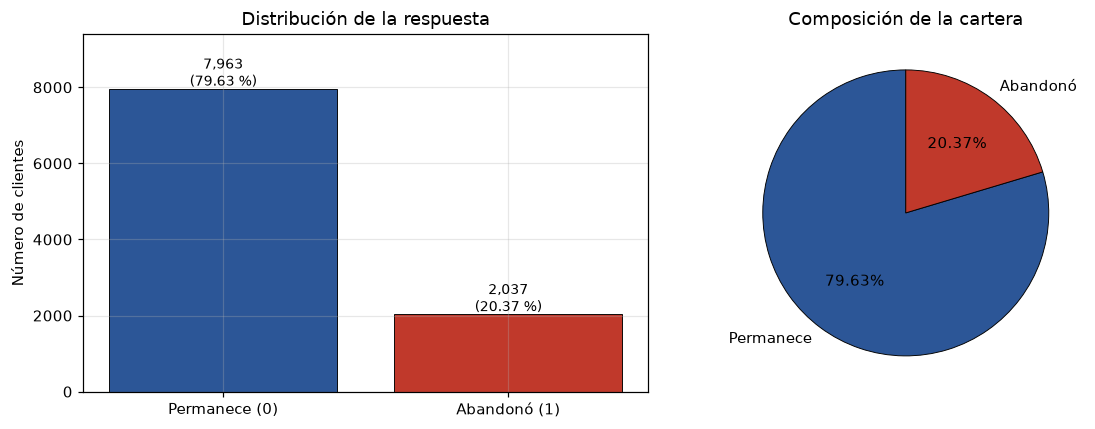

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(["Permanece (0)", "Abandonó (1)"], conteo.values,
            color=[COL_PERM, COL_ABAN], edgecolor="black", linewidth=0.6)
for i, v in enumerate(conteo.values):
    axes[0].text(i, v + 80, f"{v:,}\n({v/len(datos)*100:.2f} %)",
                 ha="center", fontsize=9)
axes[0].set_ylabel("Número de clientes")
axes[0].set_title("Distribución de la respuesta")
axes[0].set_ylim(0, conteo.max() * 1.18)

axes[1].pie(conteo.values, labels=["Permanece", "Abandonó"],
            colors=[COL_PERM, COL_ABAN], autopct="%1.2f%%",
            startangle=90, wedgeprops={"edgecolor": "black", "linewidth": 0.6})
axes[1].set_title("Composición de la cartera")

plt.tight_layout()
plt.show()

In [10]:
print("DESCRIPTIVO DE LAS VARIABLES CUANTITATIVAS")
desc = datos[CUANTITATIVAS].describe().T
desc["asimetría"] = datos[CUANTITATIVAS].skew()
display(desc.round(2))

print(f"\nClientes con saldo exactamente 0: {int((datos['saldo']==0).sum())} "
      f"({(datos['saldo']==0).mean()*100:.2f} % de la base)")

DESCRIPTIVO DE LAS VARIABLES CUANTITATIVAS


,count,mean,std,min,25%,50%,75%,max,asimetría
puntaje_crediticio,10000.0,650.53,96.65,350.00,584.00,652.00,718.00,850.00,-0.07
edad,10000.0,38.92,10.49,18.00,32.00,37.00,44.00,92.00,1.01
antiguedad,10000.0,5.01,2.89,0.00,3.00,5.00,7.00,10.00,0.01
saldo,10000.0,76485.89,62397.41,0.00,0.00,97198.54,127644.24,250898.09,-0.14
numero_productos,10000.0,1.53,0.58,1.00,1.00,1.00,2.00,4.00,0.75
salario_estimado,10000.0,100090.24,57510.49,11.58,51002.11,100193.92,149388.25,199992.48,0.00



Clientes con saldo exactamente 0: 3617 (36.17 % de la base)


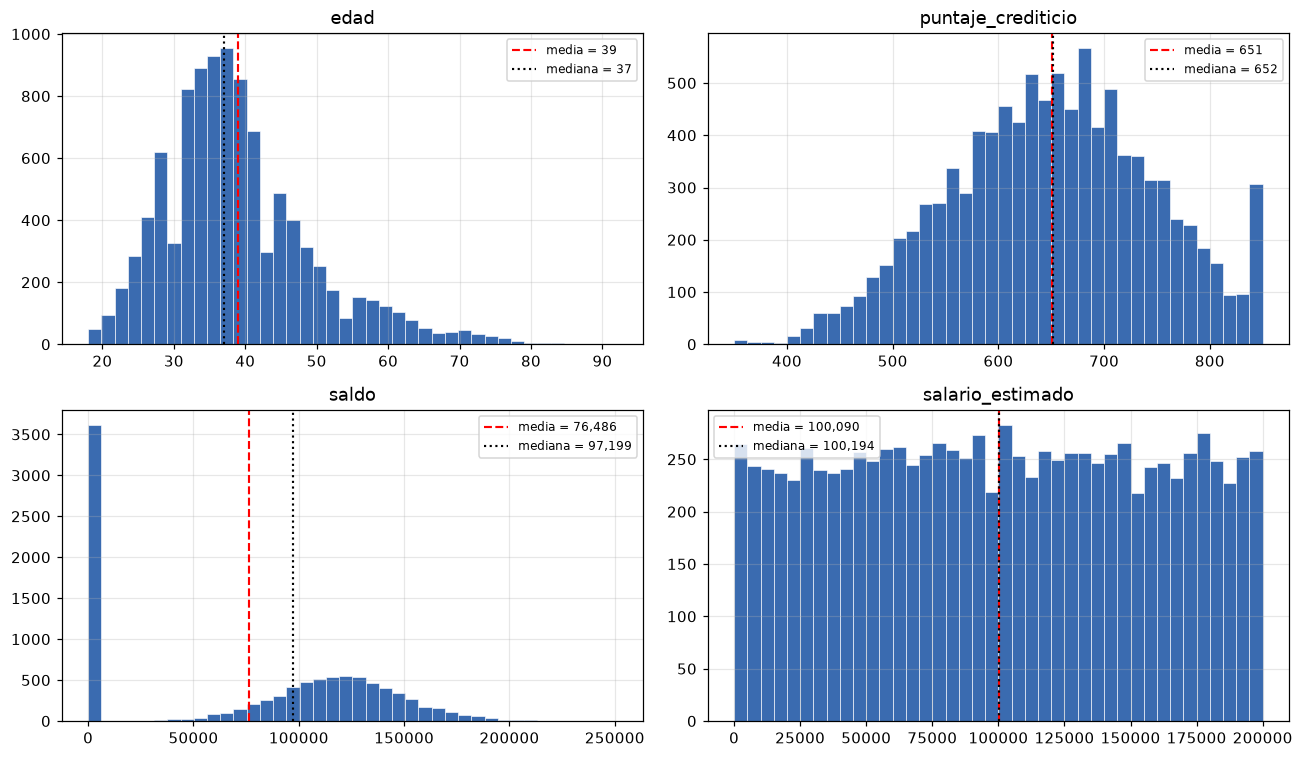

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, var in zip(axes.flat, ["edad", "puntaje_crediticio", "saldo",
                               "salario_estimado"]):
    ax.hist(datos[var], bins=40, color="#3A6BB0", edgecolor="white", linewidth=0.4)
    ax.axvline(datos[var].mean(), color="red", ls="--", lw=1.4,
               label=f"media = {datos[var].mean():,.0f}")
    ax.axvline(datos[var].median(), color="black", ls=":", lw=1.4,
               label=f"mediana = {datos[var].median():,.0f}")
    ax.set_title(var)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [12]:
print("TABLAS DE FRECUENCIA DE LAS CATEGÓRICAS Y BINARIAS\n")
for var in ["pais", "sexo", "numero_productos", "miembro_activo", "tiene_tarjeta"]:
    t = pd.DataFrame({
        "Frecuencia": datos[var].value_counts(sort=False),
        "Porcentaje": (datos[var].value_counts(normalize=True, sort=False) * 100).round(2)})
    t.index.name = var
    display(t)

TABLAS DE FRECUENCIA DE LAS CATEGÓRICAS Y BINARIAS



,Frecuencia,Porcentaje
pais,,
Francia,5014,50.14
Alemania,2509,25.09
España,2477,24.77


,Frecuencia,Porcentaje
sexo,,
Mujer,4543,45.43
Hombre,5457,54.57


,Frecuencia,Porcentaje
numero_productos,,
1,5084,50.84
3,266,2.66
2,4590,45.90
4,60,0.60


,Frecuencia,Porcentaje
miembro_activo,,
1,5151,51.51
0,4849,48.49


,Frecuencia,Porcentaje
tiene_tarjeta,,
1,7055,70.55
0,2945,29.45


### Respuestas (sección 2)

**5. ¿Qué porcentaje de la base abandonó? ¿Por qué un clasificador que siempre diga «permanece» ya
parece bueno si uno solo mira la *accuracy*?**

Abandonó el 20,37 % de la cartera: 2.037 clientes de 10.000. Permanece el 79,63 %, es decir
7.963. El desbalance es de casi 4 a 1 a favor de la clase 0.

Ese desbalance fija un piso engañoso para la exactitud. Un clasificador que ignore por completo
las variables y responda siempre «permanece» acierta en los 7.963 casos de la clase mayoritaria y
falla en los 2.037 restantes:

$$
\text{Exactitud del clasificador trivial} = \frac{7.963}{10.000} = 0{,}7963 \approx 79{,}6\,\%
$$

Casi un 80 % de aciertos sin haber aprendido nada. El problema es que su sensibilidad es
exactamente 0: no detecta a ni un solo cliente que se va, que es justamente lo único que le
interesa al área de retención.

De aquí se siguen dos consecuencias prácticas para el resto del taller:

- La exactitud solo es informativa comparada contra el 79,63 %. Un modelo con 82 % de acierto
  no es «bueno»: aporta apenas 2 puntos sobre no hacer nada.
- Hay que mirar sensibilidad y especificidad por separado (sección 6). Son los indicadores que
  distinguen un modelo útil de uno que simplemente se apoya en la clase mayoritaria.

**Lo que muestran las demás tablas.** `edad` está sesgada a la derecha (media 38,9; mediana 37;
máximo 92). `saldo` tiene una particularidad importante: 3.617 clientes (36,17 %) registran saldo exactamente cero, lo que produce una distribución bimodal (una masa en 0 y una campana alrededor
de 120.000) y no un simple sesgo. `salario_estimado` es prácticamente uniforme entre 11 y 200.000,
lo que hace sospechar que es una variable simulada y anticipa que aportará poco. En cuanto a los
factores, Francia concentra la mitad de la cartera (5.014) y Alemania y España se reparten el resto
por partes casi iguales; el 70,6 % tiene tarjeta y la base está casi partida en dos por
`miembro_activo` (51,5 % activos).

---
> 📌 Cierre de sección: `git commit -m "Punto 2: descriptivo univariado"` y `git push`.